# Thomas St Overpass Forecast

This notebook will go over the possibilities of forecasting data from the [Seattle Open Data Portal](https://data.seattle.gov/Transportation/Thomas-St-Overpass-Bike-Ped-Counter/t8i6-tipf/about_data). The dataset of interest here is the pedestrian and bicyclist traffic on the Thomas St Overpass in Seattle. 

In [36]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox
from statsmodels.tsa.seasonal import STL
import requests
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels as sm
from statsmodels.tsa.seasonal import STL
from scipy.stats import boxcox
import datetime
from pandas_datareader import data as web
import warnings
from statsmodels.tsa.stattools import acf
import yfinance as yf
from matplotlib.pylab import rcParams
warnings.filterwarnings('ignore')

In [37]:
import folium

# Thomas St Overpass coordinates
lat = 47.6189
lon = -122.3553

# Create a map centered on the overpass
m = folium.Map(location=[lat, lon], zoom_start=18)

# Add a marker for the overpass
folium.Marker(
    location=[lat, lon],
    popup="West Thomas Street Overpass\nSeattle, WA",
    tooltip="Thomas St Overpass",
    icon=folium.Icon(icon="bicycle", prefix="fa")
).add_to(m)

# Optional: add a circle around it for extra visibility
folium.Circle(
    location=[lat, lon],
    radius=80,  # meters
    color="blue",
    fill=True,
    fill_opacity=0.2
).add_to(m)

# Display in a Jupyter notebook
m

The data will be pre-processed using a helper python package I've made called Searease. Once this package gives us the pre-cleaned data with inferred frequency, we will do some diagnostic work to understand the processess that impact the time series. 

Raw DF (head):


,Time,Thomas St Overpass,Thomas St Overpass Pedestrian IN,Thomas St Overpass Pedestrian OUT,Thomas St Overpass Cyclist IN,Thomas St Overpass Cyclist OUT
0,2022 Mar 17 12:00:00 AM,2.0,2.0,0.0,0.0,0.0
1,2022 Mar 17 01:00:00 AM,0.0,0.0,0.0,0.0,0.0
2,2022 Mar 17 02:00:00 AM,1.0,0.0,0.0,1.0,0.0
3,2022 Mar 17 03:00:00 AM,0.0,0.0,0.0,0.0,0.0
4,2022 Mar 17 04:00:00 AM,2.0,0.0,2.0,0.0,0.0



Ingestion metadata:
IngestionMetadata(n_rows=28822, n_cols=6, column_names=['Time', 'Thomas St Overpass', 'Thomas St Overpass Pedestrian IN', 'Thomas St Overpass Pedestrian OUT', 'Thomas St Overpass Cyclist IN', 'Thomas St Overpass Cyclist OUT'], dtypes={'Time': 'object', 'Thomas St Overpass': 'float64', 'Thomas St Overpass Pedestrian IN': 'float64', 'Thomas St Overpass Pedestrian OUT': 'float64', 'Thomas St Overpass Cyclist IN': 'float64', 'Thomas St Overpass Cyclist OUT': 'float64'}, file_type='csv', encoding='utf-8', delimiter=',', warnings=["Encoding detection returned 'ascii'; using 'utf-8' instead."], index_is_datetime=False)

Detected schema:
  date_col   : Time
  target_col : Thomas St Overpass
  notes      : []

Cleaned DF (index + columns; head):


,Thomas St Overpass,Thomas St Overpass Pedestrian IN,Thomas St Overpass Pedestrian OUT,Thomas St Overpass Cyclist IN,Thomas St Overpass Cyclist OUT
Time,,,,,
2022-03-17 00:00:00,2.0,2.0,0.0,0.0,0.0
2022-03-17 01:00:00,0.0,0.0,0.0,0.0,0.0
2022-03-17 02:00:00,1.0,0.0,0.0,1.0,0.0
2022-03-17 03:00:00,0.0,0.0,0.0,0.0,0.0
2022-03-17 04:00:00,2.0,0.0,2.0,0.0,0.0



TimeSeriesMeta:
  start             : 2022-03-17 00:00:00
  end               : 2025-07-31 23:00:00
  freq              : h
  n_obs             : 28822
  has_missing_dates : True
  n_missing_dates   : 770
  has_duplicates    : False
  notes:
   - Pandas could not infer a frequency, but a dominant cadence of 0 days 01:00:00 (~100.0% of gaps) was detected and mapped to freq='h'. Series may still be irregular.
   - Detected 770 missing timestamps between 2022-03-17 00:00:00 and 2025-07-31 23:00:00 at frequency 'h'.


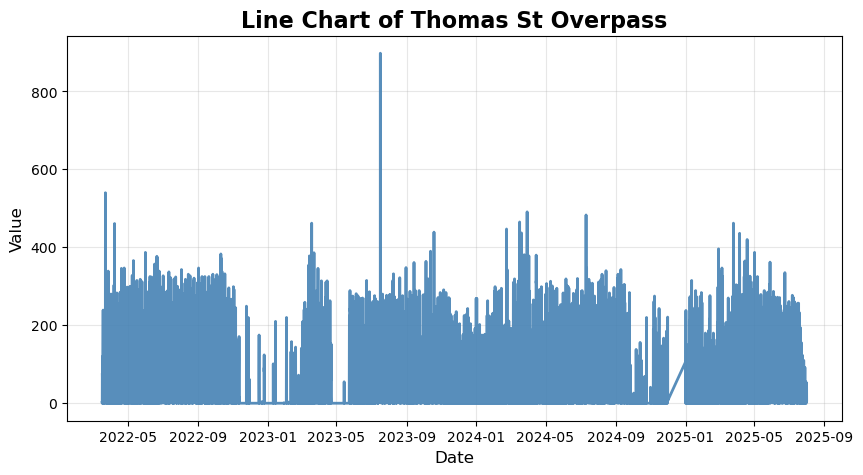

In [38]:
import sys, os

project_root = r"C:\Users\whoop\PyCharmProjects\PythonProject"
if project_root not in sys.path:
    sys.path.append(project_root)

from Serease.pre_processing import (
    DataIngestor,
    SchemaDetector,
    TimeSeriesCleaner,
)

CSV_PATH = r"C:\Users\whoop\Downloads\CSVs for TIME SERIES TESTING\Real world high volume\Thomas_St_Overpass_Bike_&_Ped_Counter_20251110.csv"
ingestor = DataIngestor(CSV_PATH)
df = ingestor.load()
ing_meta = ingestor.get_metadata()

print('Raw DF (head):')
display(df.head())
print('\nIngestion metadata:')
print(ing_meta)

schema_detector = SchemaDetector(
    df=df,
    ingestion_meta=ing_meta,
    user_target_col='Thomas St Overpass'
)

schema_meta = schema_detector.detect()

print('\nDetected schema:')
print(f"  date_col   : {schema_meta.date_col}")
print(f"  target_col : {schema_meta.target_col}")
print(f"  notes      : {schema_meta.notes}")

cleaner = TimeSeriesCleaner(
    df=df,
    schema=schema_meta,
)

cleaned_df, ts_meta = cleaner.clean()

print('\nCleaned DF (index + columns; head):')
display(cleaned_df.head())

print('\nTimeSeriesMeta:')
print(f"  start             : {ts_meta.start}")
print(f"  end               : {ts_meta.end}")
print(f"  freq              : {ts_meta.freq}")
print(f"  n_obs             : {ts_meta.n_obs}")
print(f"  has_missing_dates : {ts_meta.has_missing_dates}")
print(f"  n_missing_dates   : {ts_meta.n_missing_dates}")
print(f"  has_duplicates    : {ts_meta.has_duplicates}")
print('  notes:')
for n in ts_meta.notes:
    print('   -', n)
    pass
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(cleaned_df.index, cleaned_df[schema_meta.target_col], color='steelblue', linewidth=2.0, marker='', alpha=0.9)
plt.title(f"Line Chart of {schema_meta.target_col}", fontsize=16, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, alpha=0.3)

,Thomas St Overpass
Time,
2022-03-17,1046.0
2022-03-18,1505.0
2022-03-19,1127.0
2022-03-20,1116.0
2022-03-21,912.0


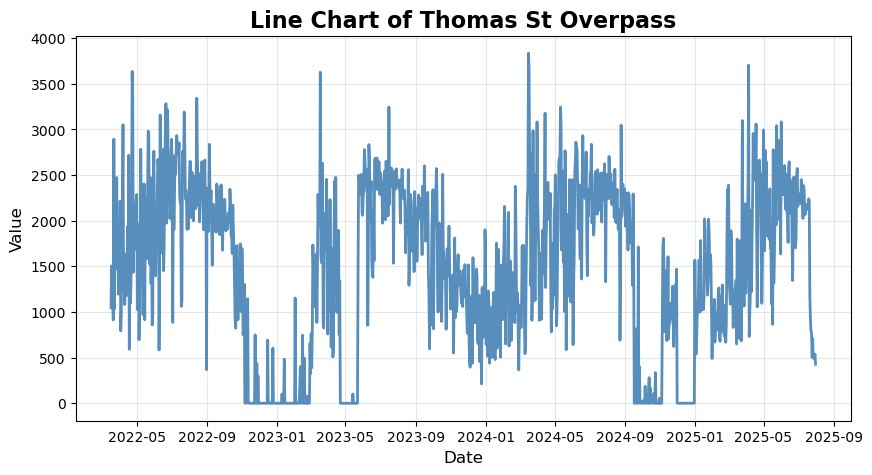

In [39]:
daily_df = cleaned_df.resample('24h').sum()
daily_df = daily_df.drop(columns=[
    'Thomas St Overpass Pedestrian IN', 
    'Thomas St Overpass Pedestrian OUT', 
    'Thomas St Overpass Cyclist IN', 
    'Thomas St Overpass Cyclist OUT'
])
display(daily_df.head())

plt.figure(figsize=(10,5))
plt.plot(daily_df.index, daily_df['Thomas St Overpass'], color='steelblue', linewidth=2.0, marker='', alpha=0.9)
plt.title(f"Line Chart of {schema_meta.target_col}", fontsize=16, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, alpha=0.3)

We've resampled the data to a daily frequency to make things more stable. It is immediately clear that there is some sort of cyclical pattern taking place so let's assess whether this is seasonality and if so we can discern the seasonal period with some visuals. 

In [40]:
def season_plot(ax, data, x, group, y, x_ticks=None, x_ticklabels=None,
                title="", ylabel=""):
    for k, g in data.groupby(group):
        g = g.sort_values(x)
        ax.plot(g[x], g[y], label=str(k))
    if x_ticks is not None:
        ax.set_xticks(x_ticks)
    if x_ticklabels is not None:
        ax.set_xticklabels(x_ticklabels)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.35)
    for s in ax.spines.values():
        s.set_visible(False)

def label_at_right(ax, data, x, group, y, label_func):
    last_x = data[x].max()
    for k, g in data.groupby(group):
        gg = g[g[x] == last_x]
        if not gg.empty:
            ax.text(last_x + 0.15, float(gg[y]), label_func(k),
                    va='center', fontsize=9)

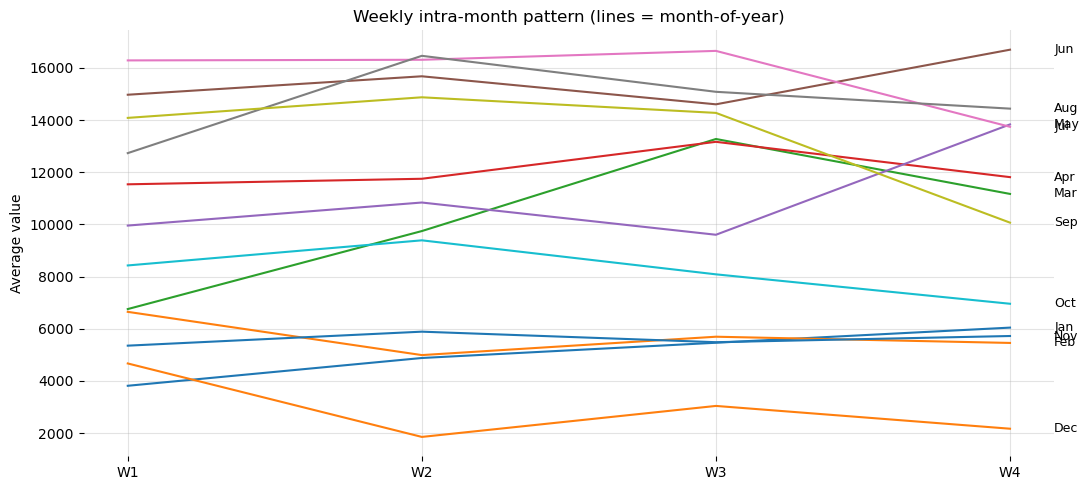

In [41]:
# Weekly data from DateTimeIndex
data_weekly = cleaned_df.resample('W').sum()

df_w = data_weekly.copy()
df_w['date'] = df_w.index
df_w['year'] = df_w['date'].dt.year
df_w['month'] = df_w['date'].dt.month
df_w['year_month'] = df_w['date'].dt.to_period('M')

# Week number within each month (1, 2, 3, 4, 5...)
df_w = df_w.sort_values('date')
df_w['week_in_month'] = df_w.groupby('year_month').cumcount() + 1

# Keep only the first 4 weeks of each month
df_w = df_w[df_w['week_in_month'] <= 4]

df_w['value'] = df_w['Thomas St Overpass']

# Average across years: one line per month-of-year
intra_month_all = (
    df_w.groupby(['month', 'week_in_month'], as_index=False)['value']
        .mean()
)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(11, 5))

season_plot(
    ax,
    intra_month_all,
    x='week_in_month',
    group='month',   # lines = month-of-year
    y='value',
    x_ticks=[1, 2, 3, 4],
    x_ticklabels=['W1', 'W2', 'W3', 'W4'],
    title='Weekly intra-month pattern (lines = month-of-year)',
    ylabel='Average value'
)

label_at_right(
    ax,
    intra_month_all,
    x='week_in_month',
    group='month',
    y='value',
    label_func=lambda m: month_labels[int(m) - 1]
)

plt.tight_layout()
plt.show()

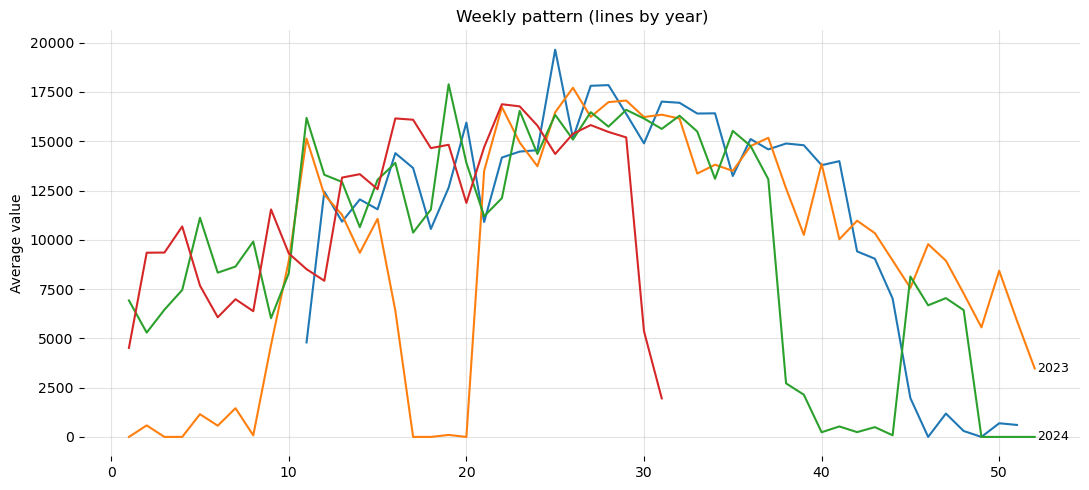

In [42]:
# Weekly data from DateTimeIndex
data_weekly = cleaned_df.resample('W').sum()

df_w = data_weekly.copy()
df_w['date'] = df_w.index
df_w['year'] = df_w['date'].dt.year
df_w['week'] = df_w['date'].dt.isocalendar().week.astype(int)
df_w['value'] = df_w['Thomas St Overpass']

weekly_intra_year = (
    df_w.groupby(['year', 'week'], as_index=False)['value']
        .mean()
)

fig, ax = plt.subplots(figsize=(11, 5))

season_plot(
    ax,
    weekly_intra_year,
    x='week',
    group='year',
    y='value',
    title='Weekly pattern (lines by year)',
    ylabel='Average value'
)

label_at_right(ax, weekly_intra_year, x='week', group='year', y='value',
               label_func=lambda yr: str(yr))

plt.tight_layout()
plt.show()


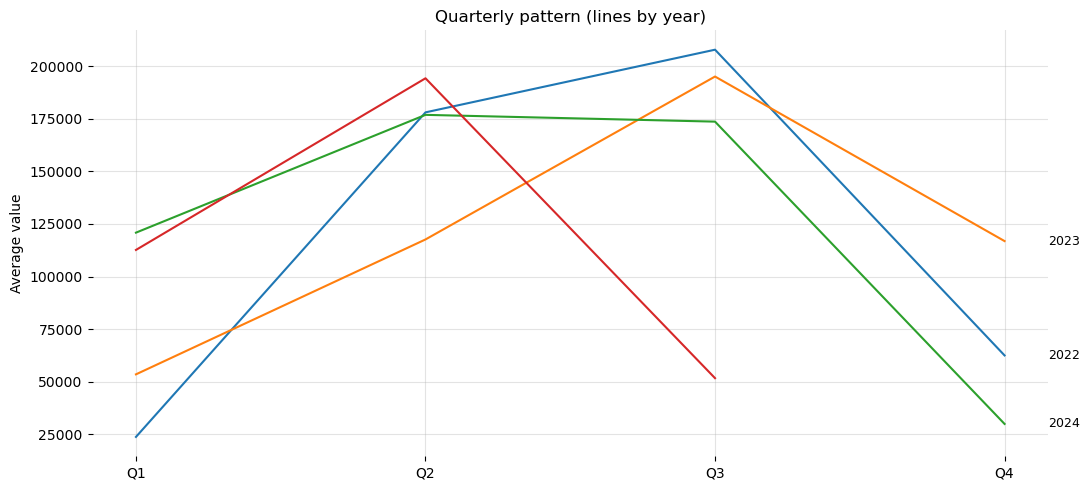

In [43]:
# Quarterly data from DateTimeIndex
data_quarterly = cleaned_df.resample('Q').sum()

df_q = data_quarterly.copy()
df_q['date'] = df_q.index
df_q['year'] = df_q['date'].dt.year
df_q['quarter'] = df_q['date'].dt.quarter
df_q['value'] = df_q['Thomas St Overpass']

quarterly_intra_year = (
    df_q.groupby(['year', 'quarter'], as_index=False)['value']
        .mean()
)

fig, ax = plt.subplots(figsize=(11, 5))

season_plot(
    ax,
    quarterly_intra_year,
    x='quarter',
    group='year',
    y='value',
    x_ticks=[1, 2, 3, 4],
    x_ticklabels=['Q1', 'Q2', 'Q3', 'Q4'],
    title='Quarterly pattern (lines by year)',
    ylabel='Average value'
)

label_at_right(ax, quarterly_intra_year, x='quarter', group='year', y='value',
               label_func=lambda yr: str(yr))

plt.tight_layout()
plt.show()


## Graphical Interpretation:

So above we see three plots:
1. Intra-month weekly data
2. Intra-year weekly data
3. Intra-year quarterly data

For the first plot we see that week to week the traffic does not change much if any at all during the month. Then when we pull time frame to intra-year at a weekly frequency, we can see the yearly seasonality. The data resembles a sine wave, having consistent peaks every summer and falling back down to a trough every winter. Since we are sticking with a weekly frequency, our seasonal period is 52, meaning 52 weeks. We need to visualize the seasonal period, any trends present in the data, as well as the points where there are points that seasonality and trend cannot account for. 

In [44]:
weekly_df = cleaned_df.resample('W').sum()
display(weekly_df.head())

,Thomas St Overpass,Thomas St Overpass Pedestrian IN,Thomas St Overpass Pedestrian OUT,Thomas St Overpass Cyclist IN,Thomas St Overpass Cyclist OUT
Time,,,,,
2022-03-20,4794.0,2786.0,1841.0,78.0,89.0
2022-03-27,12444.0,7341.0,4565.0,249.0,289.0
2022-04-03,10921.0,6249.0,4103.0,238.0,331.0
2022-04-10,12049.0,6994.0,4238.0,390.0,427.0
2022-04-17,11546.0,6887.0,4197.0,184.0,278.0


Below we use a Box-Cox transform to ensure trend stationarity then create a seasonal trend decomposition to look at the trend, seasonality, and resiudal components of the series seperated. 

Lambda: 1.0282129025874462


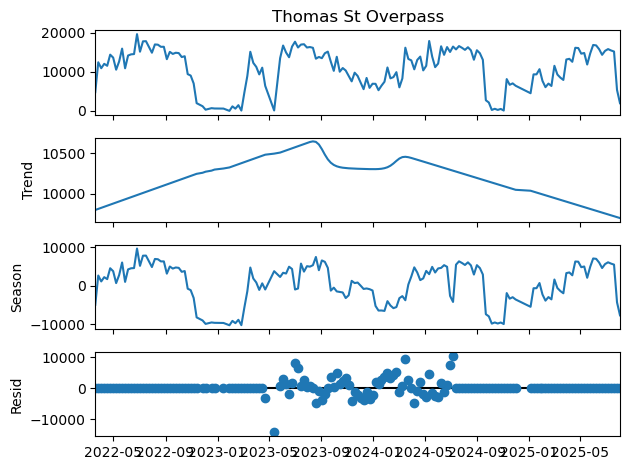

In [45]:
s = weekly_df['Thomas St Overpass']
s = s.dropna()
s = s[s > 0]

y_bc, lam = boxcox(s.values)
print("Lambda:", lam)

stl = STL(s, period=52, robust=True)
res = stl.fit()

res.plot()
plt.tight_layout()
plt.show()

We see that there are tons of residuals when our data deviates from its seasonal pattern. For a SARIMAX model, we will need to find some data to explain these points where predictions are inconsistent. We will query some databases with SQL and find histrocial data from APIs to find a feature that correlates strongly with the residuals we see. But before that we will do some preliminary work to set up parameters of a baseline SARIMAX and establish baseline models in general. 

In [46]:
y = s
display(y.head())

def interpret_adf(result):
    p = result[1]
    return "stationary (reject unit root)" if p < 0.05 else "non-stationary (fail to reject unit root)"

def interpret_kpss(result):
    p = result[1]
    return "stationary (fail to reject stationarity)" if p > 0.05 else "non-stationary (reject stationarity)"

# ---------------------------
# Original series
# ---------------------------
adf_orig = adfuller(y)
kpss_orig = kpss(y, regression="c", nlags="auto")

print("Original series:")
print(f"  ADF stat : {adf_orig[0]:.4f}")
print(f"  ADF p-val: {adf_orig[1]:.4f} → {interpret_adf(adf_orig)}")
print(f"  KPSS stat: {kpss_orig[0]:.4f}")
print(f"  KPSS p-val: {kpss_orig[1]:.4f} → {interpret_kpss(kpss_orig)}\n")

Time
2022-03-20     4794.0
2022-03-27    12444.0
2022-04-03    10921.0
2022-04-10    12049.0
2022-04-17    11546.0
Name: Thomas St Overpass, dtype: float64

Original series:
  ADF stat : -3.6943
  ADF p-val: 0.0042 → stationary (reject unit root)
  KPSS stat: 0.0584
  KPSS p-val: 0.1000 → stationary (fail to reject stationarity)



Stationarity check passed

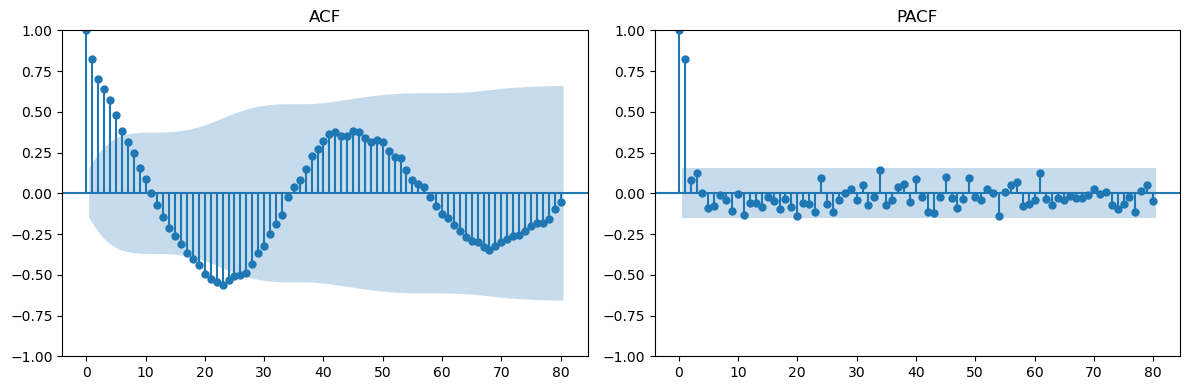

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(y, lags=80, ax=axes[0])
axes[0].set_title("ACF")

plot_pacf(y, lags=80, ax=axes[1], method='ywm')
axes[1].set_title("PACF")

plt.tight_layout()
plt.show()

Partial Auto-Correlation Function and Auto-Correlation function show evidence of an Auto-Regressive lag 1 structure. We will fit a SARIMAX model with the parameters (1,0,0)x(0,0,0,0) and graph it versus a validation period. 

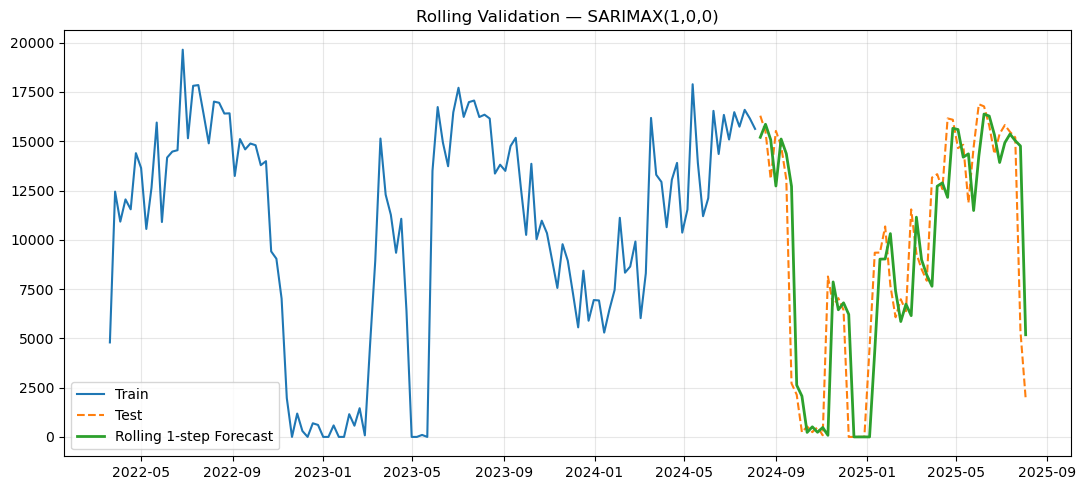

In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import matplotlib.pyplot as plt

y = weekly_df['Thomas St Overpass'].copy()

n_test = 52
y_train_full = y.iloc[:-n_test]
y_test = y.iloc[-n_test:]

rolling_preds = []
rolling_index = []

for i in range(n_test):
    # expanding training window
    y_train = y.iloc[:len(y) - n_test + i]
    y_true  = y.iloc[len(y) - n_test + i]

    model = SARIMAX(
        y_train,
        order=(1, 0, 0),
        enforce_stationarity=True,
        enforce_invertibility=True
    )

    results = model.fit(disp=False)

    forecast = results.get_forecast(steps=1)
    y_pred = forecast.predicted_mean.iloc[0]

    rolling_preds.append(y_pred)
    rolling_index.append(y.index[len(y) - n_test + i])

y_pred_rolling = pd.Series(rolling_preds, index=rolling_index)

plt.figure(figsize=(11, 5))
plt.plot(y_train_full.index, y_train_full, label='Train')
plt.plot(y_test.index, y_test, label='Test', linestyle='--')
plt.plot(y_pred_rolling.index, y_pred_rolling, label='Rolling 1-step Forecast', linewidth=2)

plt.title('Rolling Validation — SARIMAX(1,0,0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Above we can see the validation period in orange, model predictions in green, the predictions follow the real validation data very well. For this next section we will look at the residuals to ensure no structure in the data was left un-captured. After that we will look at the Mean Absolute Scaled Error (MASE) of our model and some other basic models. The MASE will tell us how well models do in comparison to a model that simply predicts the mean of the data. 

                               SARIMAX Results                                
Dep. Variable:     Thomas St Overpass   No. Observations:                  125
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -1169.534
Date:                Mon, 09 Feb 2026   AIC                           2343.068
Time:                        11:39:10   BIC                           2348.725
Sample:                    03-20-2022   HQIC                          2345.366
                         - 08-04-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9727      0.024     41.384      0.000       0.927       1.019
sigma2      7.704e+06    5.6e+05     13.751      0.000    6.61e+06     8.8e+06
Ljung-Box (L1) (Q):                   0.87   Jarque-

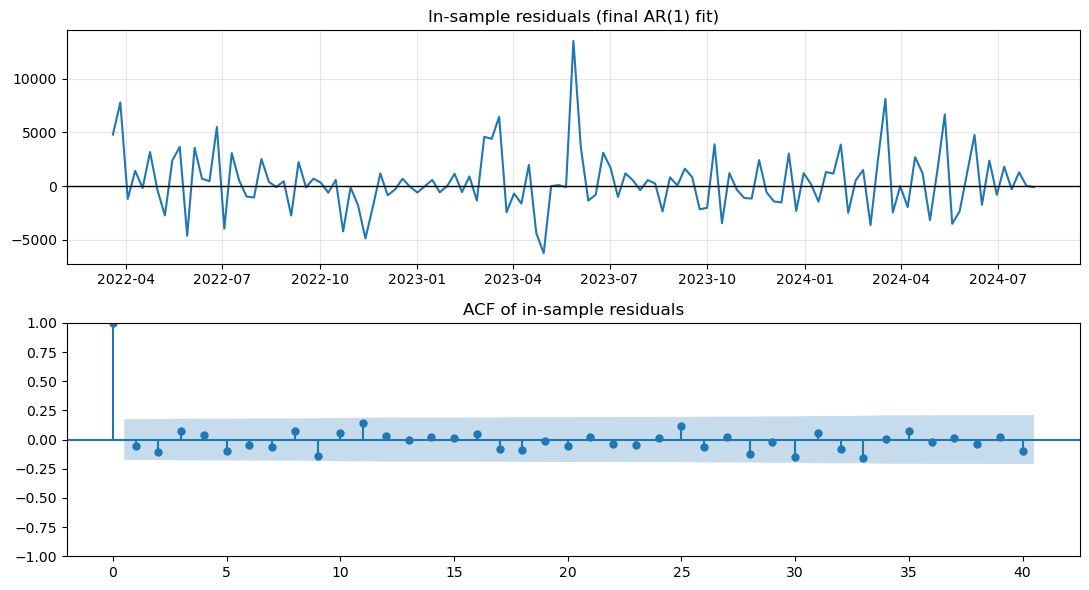

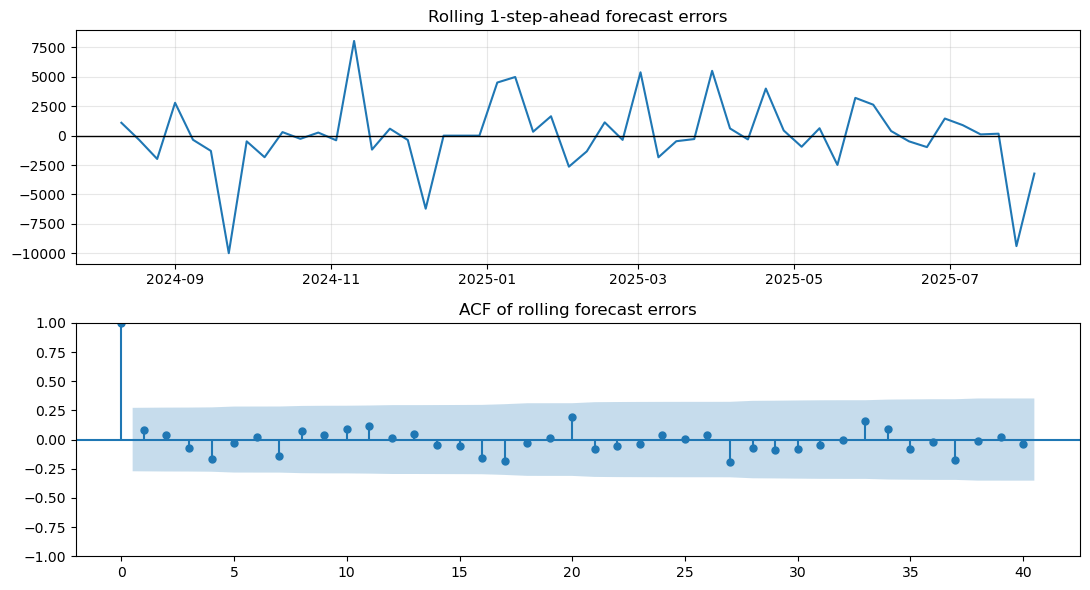

Rolling 1-step-ahead MASE: 0.447


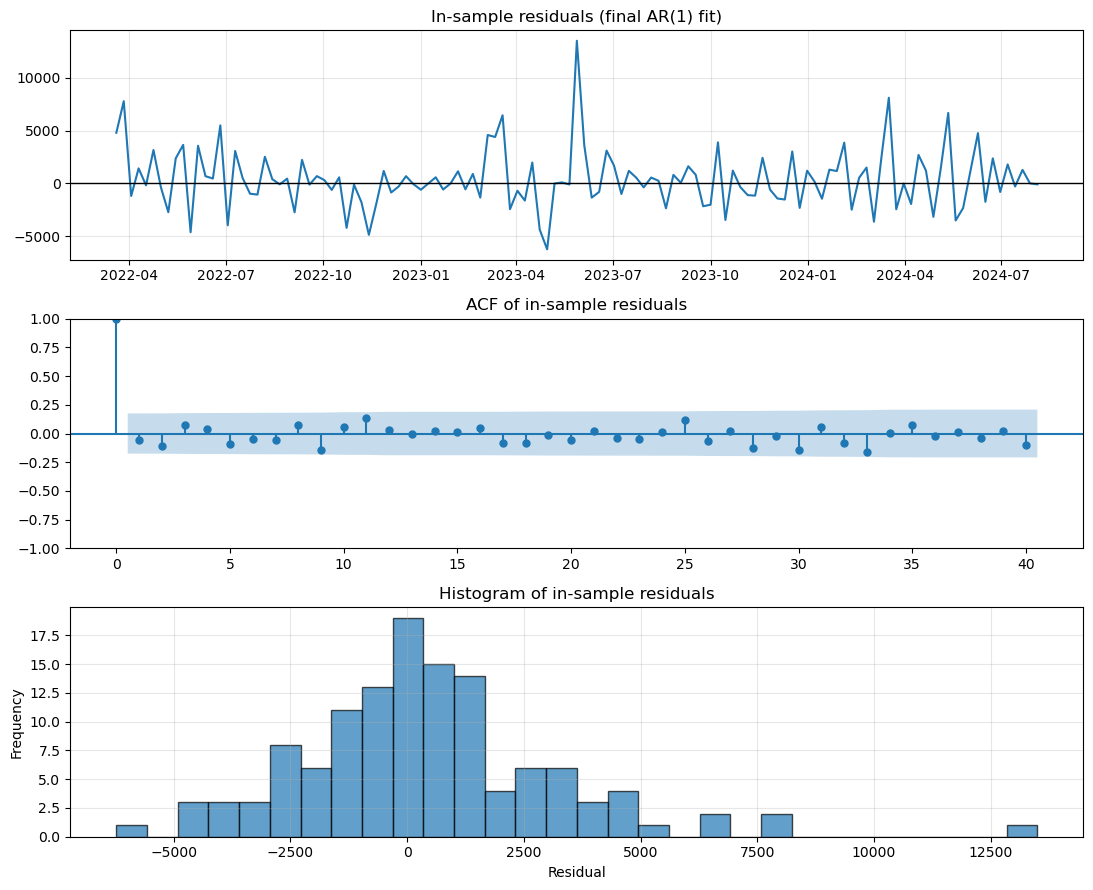

In [49]:
# ---------------------------
# Data
# ---------------------------
y = weekly_df['Thomas St Overpass'].copy()

n_test = 52
m = 52  # seasonal period for MASE scaling

y_train_full = y.iloc[:-n_test]
y_test = y.iloc[-n_test:]

# ---------------------------
# Fit final model (for in-sample diagnostics)
# ---------------------------
model = SARIMAX(
    y_train_full,
    order=(1, 0, 0),
    enforce_stationarity=True,
    enforce_invertibility=True
)

results = model.fit(disp=False)
print(results.summary())

# ---------------------------
# In-sample residual diagnostics
# ---------------------------
resid = results.resid.dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 6))

axes[0].plot(resid)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('In-sample residuals (final AR(1) fit)')
axes[0].grid(True, alpha=0.3)

plot_acf(resid, ax=axes[1], lags=40)
axes[1].set_title('ACF of in-sample residuals')

plt.tight_layout()
plt.show()

# ---------------------------
# Rolling 1-step-ahead validation
# ---------------------------
rolling_preds = []
rolling_index = []

for i in range(n_test):
    train_end = len(y) - n_test + i

    y_train = y.iloc[:train_end]
    y_true  = y.iloc[train_end]

    model = SARIMAX(
        y_train,
        order=(1, 0, 0),
        enforce_stationarity=True,
        enforce_invertibility=True
    )

    results_i = model.fit(disp=False)
    forecast = results_i.get_forecast(steps=1)
    y_pred = forecast.predicted_mean.iloc[0]

    rolling_preds.append(y_pred)
    rolling_index.append(y.index[train_end])

y_pred_rolling = pd.Series(rolling_preds, index=rolling_index)

# ---------------------------
# Rolling forecast error diagnostics
# ---------------------------
rolling_errors = y_test - y_pred_rolling

fig, axes = plt.subplots(2, 1, figsize=(11, 6))

axes[0].plot(rolling_errors)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Rolling 1-step-ahead forecast errors')
axes[0].grid(True, alpha=0.3)

plot_acf(rolling_errors.dropna(), ax=axes[1], lags=40)
axes[1].set_title('ACF of rolling forecast errors')

plt.tight_layout()
plt.show()

# ---------------------------
# MASE (rolling validation)
# ---------------------------
# seasonal naive scale (training only)
insample_diff = (y_train_full[m:] - y_train_full.shift(m)[m:]).dropna()
scale = np.mean(np.abs(insample_diff))

mase_rolling = np.mean(np.abs(rolling_errors)) / scale
print(f"Rolling 1-step-ahead MASE: {mase_rolling:.3f}")

# ---------------------------
# In-sample residual diagnostics
# ---------------------------
resid = results.resid.dropna()

fig, axes = plt.subplots(3, 1, figsize=(11, 9))

# Residual time series
axes[0].plot(resid)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('In-sample residuals (final AR(1) fit)')
axes[0].grid(True, alpha=0.3)

# Residual ACF
plot_acf(resid, ax=axes[1], lags=40)
axes[1].set_title('ACF of in-sample residuals')

# Residual histogram
axes[2].hist(resid, bins=30, edgecolor='black', alpha=0.7)
axes[2].set_title('Histogram of in-sample residuals')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The residuals are somewhat skewed, but there is no pattern present in the residuals that can be easily be seen. We will move on to the MASE assessment.

                           MASE
Naive (t−1)            0.455783
Seasonal naive (t−52)  0.944406
Mean (rolling)         1.182192
SARIMAX(1,0,0)         0.447387


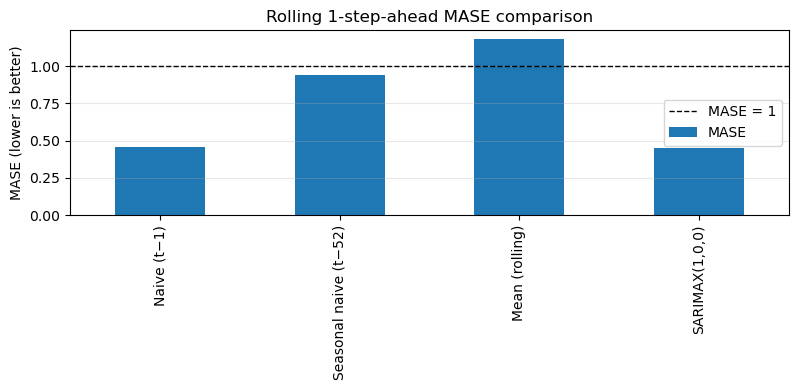

                           MASE  sMAPE (%)
Naive (t−1)            0.455783  38.318051
Seasonal naive (t−52)  0.944406  60.062221
Mean (rolling)         1.182192  66.966541
SARIMAX(1,0,0)         0.447387  38.118568


In [50]:
m = 52  # seasonal period (weekly data)

# ---------------------------
# Common scaling term (training only)
# ---------------------------
insample_diff = (y_train_full[m:] - y_train_full.shift(m)[m:]).dropna()
scale = np.mean(np.abs(insample_diff))

# ---------------------------
# Baseline 1: naive (last observed value, rolling)
# ---------------------------
naive_forecast = y.shift(1).loc[y_test.index]
mase_naive = np.mean(np.abs(y_test - naive_forecast)) / scale

# ---------------------------
# Baseline 2: seasonal naive (same week last year)
# ---------------------------
seasonal_naive_forecast = y.shift(m).loc[y_test.index]
mase_seasonal_naive = np.mean(np.abs(y_test - seasonal_naive_forecast)) / scale

# ---------------------------
# Baseline 3: mean-of-training (expanding mean, rolling)
# ---------------------------
rolling_means = []
for i in range(n_test):
    train_end = len(y) - n_test + i
    rolling_means.append(y.iloc[:train_end].mean())

mean_forecast = pd.Series(rolling_means, index=y_test.index)
mase_mean = np.mean(np.abs(y_test - mean_forecast)) / scale

# ---------------------------
# SARIMAX rolling MASE (from previous block)
# ---------------------------
mase_sarimax = np.mean(np.abs(rolling_errors)) / scale

# ---------------------------
# Collect results
# ---------------------------
mase_values = {
    'Naive (t−1)': mase_naive,
    'Seasonal naive (t−52)': mase_seasonal_naive,
    'Mean (rolling)': mase_mean,
    'SARIMAX(1,0,0)': mase_sarimax
}

mase_df = pd.DataFrame.from_dict(mase_values, orient='index', columns=['MASE'])
print(mase_df)

# ---------------------------
# Bar chart of MASEs
# ---------------------------
plt.figure(figsize=(8, 4))
mase_df['MASE'].plot(kind='bar')
plt.axhline(1.0, color='black', linestyle='--', linewidth=1, label='MASE = 1')
plt.ylabel('MASE (lower is better)')
plt.title('Rolling 1-step-ahead MASE comparison')
plt.grid(True, axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

import numpy as np
import pandas as pd

# ---------------------------
# Helper: safe sMAPE
# ---------------------------
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
    return np.mean(2 * np.abs(y_true - y_pred) / denom) * 100


# ---------------------------
# sMAPE for rolling forecasts
# ---------------------------
smape_naive = smape(y_test, naive_forecast)
smape_seasonal_naive = smape(y_test, seasonal_naive_forecast)
smape_mean = smape(y_test, mean_forecast)
smape_sarimax = smape(y_test, y_pred_rolling)

metrics_df = pd.DataFrame({
    "MASE": [
        mase_naive,
        mase_seasonal_naive,
        mase_mean,
        mase_sarimax
    ],
    "sMAPE (%)": [
        smape_naive,
        smape_seasonal_naive,
        smape_mean,
        smape_sarimax
    ]
}, index=[
    "Naive (t−1)",
    "Seasonal naive (t−52)",
    "Mean (rolling)",
    "SARIMAX(1,0,0)"
])

print(metrics_df)

Above we see that the Mean Absolute Scaled Error for our model is the best out of the baseline models we tested, showing that the model outperforms baselines. In the end our model was able to predict the future values in our validation run with a mean absolute percent error of 38.12%, meaning our errors were typicaly off by only ~38%. The patterns present in pedestrian and bicylist traffic are highly auto-regressive and modeling this structure gives a competent predictor of traffic in a given week. 